In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup 
import requests 

**Scrapping of Books Data**

In [2]:
url = "https://books.toscrape.com/catalogue/page-1.html"
product_name = []
price = []
rating = []

response = requests.get(url)
soup = BeautifulSoup(response.text,"html.parser")

books = soup.find_all("article",class_ = "product_pod")

for book in books:
    name = book.h3.a["title"]
    product_name.append(name)

    price_value = book.find("p", class_ = "price_color").text
    price.append(price_value[1:])

    rating_value = book.p["class"][1]
    rating.append(rating_value)

df = pd.DataFrame({
    "Product" : product_name,
    "Price" : price,
    "Rating" : rating 
})

df.to_csv("products.csv",index = False)

print("Data saved Successfully")


Data saved Successfully


**Data Analysis**

In [3]:
df = pd.read_csv("products.csv")

# Remove the pound symbol (£) from the Price column before converting to float
df["Price"] = df["Price"].str.replace('£', '').astype(float)

rating_map = {
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5
}

df["Rating"] = df["Rating"].map(rating_map)

print("Average Price: ",np.mean(df["Price"]))
print("Max Price: ",np.max(df["Price"]))
print("Min Price: ",np.min(df["Price"]))


print("\n Top Rated Products")
print(df.sort_values(by="Rating",ascending=False).head())

Average Price:  38.048500000000004
Max Price:  57.25
Min Price:  13.99

 Top Rated Products
                                              Product  Price  Rating
12                                        Set Me Free  17.46       5
13  Scott Pilgrim's Precious Little Life (Scott Pi...  52.29       5
14                          Rip it Up and Start Again  35.02       5
4               Sapiens: A Brief History of Humankind  54.23       5
11                              Shakespeare's Sonnets  20.66       4


**Visualization**

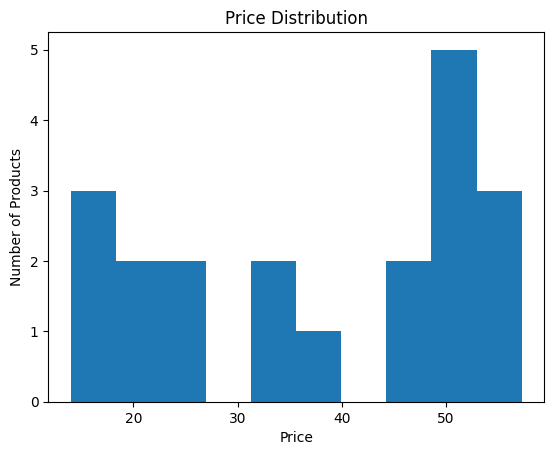

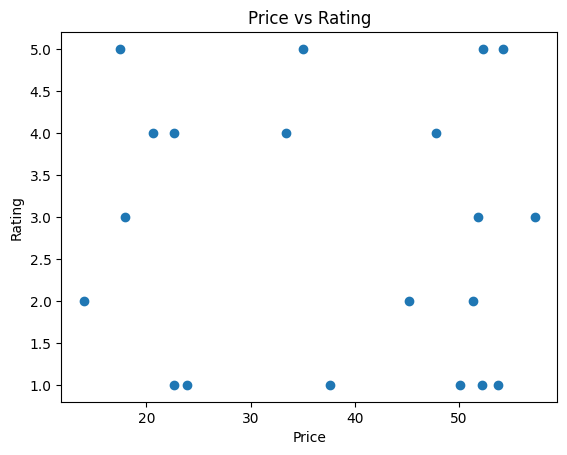

In [4]:
plt.hist(df["Price"],bins=10)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()


plt.scatter(df["Price"],df["Rating"])

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()


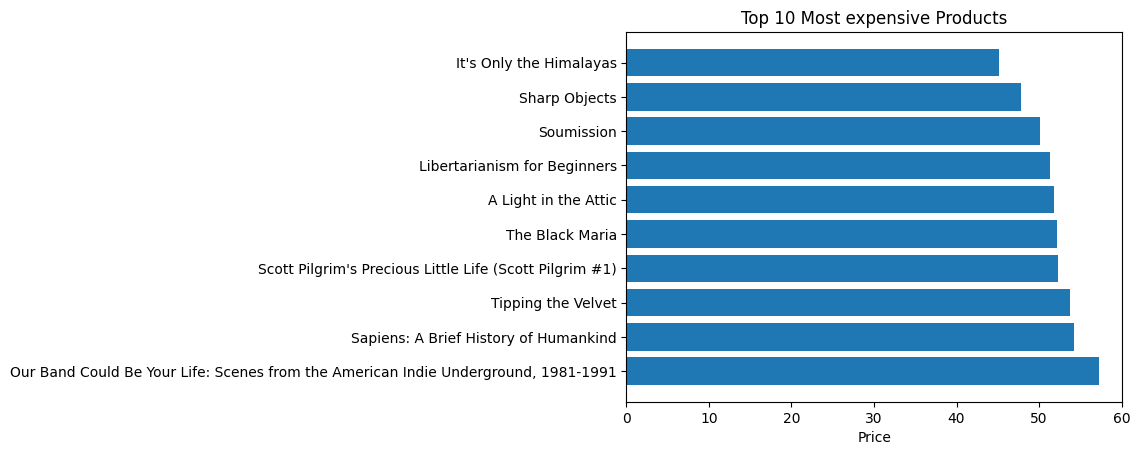

In [34]:
top10 = df.sort_values(by = "Price",ascending=False).head(10)

plt.barh(top10["Product"],top10["Price"])
plt.title("Top 10 Most expensive Products")
plt.xlabel("Price")

plt.show()